In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [6]:
data = pd.DataFrame({
    "Feature_1": np.random.randn(100),
    "Feature_2": np.random.randn(100),
    "Target": np.random.randint(2, size=100)
})

data.to_csv("datos.csv", index=False)

In [7]:
data = pd.read_csv("datos.csv")
data.head()

,Feature_1,Feature_2,Target
0,-0.006600,0.607471,1
1,-2.769141,1.651883,0
2,1.310168,1.838194,0
3,0.464150,-1.550035,0
4,0.123470,-1.514117,0


In [20]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = LogisticRegression()

In [23]:
model.fit(X_train, y_train)

LogisticRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


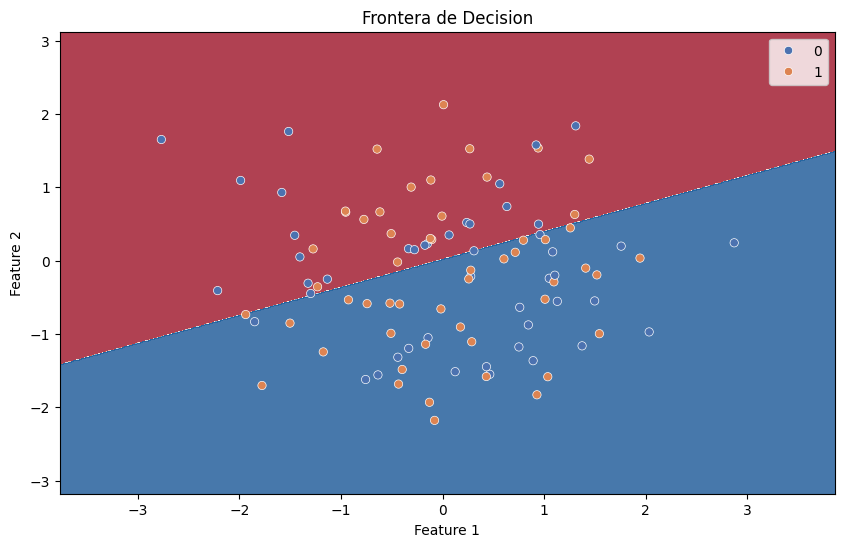

In [27]:
x_min, x_max = X["Feature_1"].min()-1 , X["Feature_1"].max() +1
y_min, y_max = X["Feature_2"].min()-1 , X["Feature_2"].max() +1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
sns.scatterplot(x="Feature_1", y="Feature_2", hue="Target", data=data, palette="deep", edgecolor="w")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Frontera de Decision")
plt.legend(loc="best")
plt.show()